# Curva DI e Selic implícita por reunião do Copom — guia do projeto

Este notebook é o guia completo do repositório. Ele explica **o que o projeto faz, por que cada conta é feita do jeito que é e como usar cada parte**, rodando tudo com dados reais da B3.

**O que você encontra aqui:**

1. Como usar
2. Os dados
3. O contrato DI1 em 5 minutos
4. A curva do dia
5. O que a curva precifica para o Copom
6. Movimentos da curva
7. Carry, roll-down e valor relativo
8. Comentário de mercado automático
9. Dashboard, figuras e testes
10. Mapa do código e próximos passos
11. Glossário

> **A pergunta que o projeto responde:** *o que a curva de juros está dizendo hoje, e que posição isso sugere?* Para isso ele monta a curva DI a partir dos contratos da B3, extrai quanto de corte ou alta da Selic está precificado em cada reunião do Copom, decompõe os movimentos diários da curva e mede carry e valor relativo entre vértices.

## 1. Como usar

**Instalação** (uma vez só), a partir da pasta do repositório:

```bash
python -m venv .venv
source .venv/bin/activate        # no Windows: .venv\Scripts\activate
pip install -r requirements.txt
```

**Dados.** Na primeira execução, o projeto baixa o histórico de ajustes do DI1 desde 2018 (≈10 MB) e salva em `data/`. Depois disso, tudo roda offline. Para atualizar a qualquer momento:

```bash
python scripts/atualizar_dados.py
```

**Este notebook.** Rode as células em ordem (*Run All*). Troque `ATUALIZAR = True` na célula abaixo para baixar os dados mais recentes antes das análises.

A célula a seguir prepara o ambiente: acha a pasta `src/` do projeto e configura os gráficos. Eles ficam interativos no Jupyter e no VS Code, e viram imagem estática quando o notebook é visto no GitHub.

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Markdown, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from curva_di import calendario, comentario, copom, dados, graficos, movimentos, valor_relativo
from curva_di.config import ARQUIVO_HISTORICO_DI1
from curva_di.curva import CurvaDI, dv01, pu, taxa_de_pu, vertices_constantes

# Gráficos: interativos no Jupyter/VS Code + PNG embutido para aparecer no GitHub.
# Sem kaleido/Chrome instalados, ficam só interativos (o que já basta para uso local).
try:
    pio.to_image(go.Figure(), format="png", width=10, height=10)
    pio.renderers.default = "plotly_mimetype+png"
    pio.renderers["png"].width = 1000
except Exception:
    pass

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

## 2. Os dados

| Fonte | O que é | Uso no projeto |
|---|---|---|
| **B3 — boletim de preços (SPRD)** | Um arquivo por pregão com o ajuste de todos os derivativos | Taxa e PU de ajuste de cada vencimento do DI1 |
| **Espelho histórico** | Os mesmos campos do boletim da B3 desde 2018, publicados pelo projeto open source [PYield](https://github.com/crdcj/PYield) | Montar o histórico inicial de uma vez, sem baixar ~2.000 arquivos |
| **BCB — SGS** | Meta Selic (série 432) e CDI (série 4389) | Selic vigente e decisões realizadas (opcional) |
| **BCB — Focus** | Mediana dos economistas para a Selic em cada reunião | Comparar mercado × economistas (opcional) |
| **BCB — Copom** | Datas das reuniões (atas + agenda oficial) | Calendário; sem internet, usa a lista embutida 2024–2027 |

As partes do BCB são **opcionais**: tudo o que depende só da curva (inclusive a Selic implícita) funciona apenas com os dados da B3.

In [2]:
ATUALIZAR = False   # True = baixa os dados mais recentes (B3 e BCB) antes de analisar

primeira_vez = not ARQUIVO_HISTORICO_DI1.exists()
if ATUALIZAR or primeira_vez:
    historico = dados.atualizar_historico_di1()
else:
    historico = dados.carregar_historico_di1()

reunioes = copom.carregar_reunioes_copom(atualizar=ATUALIZAR or primeira_vez)
selic_cdi = dados.carregar_selic_cdi(atualizar=ATUALIZAR or primeira_vez)
focus = dados.carregar_focus_selic(atualizar=ATUALIZAR or primeira_vez)

print(f"DI1: {historico['data'].nunique()} pregões, de {historico['data'].min():%d/%m/%Y} a {historico['data'].max():%d/%m/%Y} "
      f"({len(historico):,} linhas contrato × dia)")
print(f"Copom: {len(reunioes)} reuniões no calendário (fonte: {reunioes['fonte'].iloc[-1]})")
print(f"BCB Selic/CDI: {'ok' if selic_cdi is not None else 'indisponível — análises seguem só com a curva'}")
print(f"Focus: {'ok' if focus is not None else 'indisponível — a comparação com o Focus fica de fora'}")
historico.tail()

DI1: 2169 pregões, de 02/01/2018 a 23/09/2026 (83,617 linhas contrato × dia)
Copom: 32 reuniões no calendário (fonte: embutido)
BCB Selic/CDI: indisponível — análises seguem só com a curva
Focus: indisponível — a comparação com o Focus fica de fora


,data,codigo,vencimento,du,taxa,pu,contratos_abertos,contratos_negociados,fonte
83612,2026-09-23,DI1F37,2037-01-02,2573,0.14040,26147.36,393373.0,11378.0,espelho B3
83613,2026-09-23,DI1F38,2038-01-04,2822,0.14030,22986.68,56022.0,45.0,espelho B3
83614,2026-09-23,DI1F39,2039-01-03,3073,0.14000,20233.78,45368.0,NaN,espelho B3
83615,2026-09-23,DI1F40,2040-01-02,3324,0.13986,17786.95,47921.0,NaN,espelho B3
83616,2026-09-23,DI1F41,2041-01-02,3574,0.13977,15638.23,24532.0,NaN,espelho B3


Cada linha é **um contrato em um dia**. `du` são os dias úteis até o vencimento, `taxa` é a taxa de ajuste em decimal (0,1365 = 13,65% a.a.) e `pu` é o preço de ajuste.

**Checagem de qualidade.** Se o calendário de dias úteis estiver certo, a taxa recalculada a partir do PU tem de bater com a taxa publicada pela B3, que vem arredondada em 3 casas. A célula abaixo faz essa conta para todo o histórico.

In [3]:
teste = historico[historico["du"] >= 5]
taxa_recalculada = taxa_de_pu(teste["pu"], teste["du"])
bate = (taxa_recalculada * 100).round(3).sub(teste["taxa"] * 100).abs() < 1e-6
print(f"Taxas reproduzidas: {bate.mean():.4%} de {len(teste):,} contratos (vencimentos com 5+ dias úteis)")

Taxas reproduzidas: 99.9976% de 83,209 contratos (vencimentos com 5+ dias úteis)


## 3. O contrato DI1 em 5 minutos

- O **CDI** é a taxa média dos empréstimos de um dia entre bancos, que anda colada na Selic (hoje, cerca de 0,10 p.p. abaixo da meta).
- O **DI1** é o futuro de CDI da B3. Ele vale **R$ 100.000 no vencimento**, que é o 1º dia útil do mês indicado pelo código: F=jan, G=fev, H=mar, J=abr, K=mai, M=jun, N=jul, Q=ago, U=set, V=out, X=nov, Z=dez. Assim, `DI1F27` vence em janeiro de 2027.
- O contrato é **negociado em taxa** e liquidado em PU:

$$PU = \frac{100.000}{(1+\text{taxa})^{du/252}}$$

- **Tomar taxa** (vender PU) ganha se os juros subirem. **Dar taxa** (comprar PU) ganha se os juros caírem.
- O **DV01** é quanto o PU muda para 1 bp de taxa. Ele cresce com o prazo, e por isso um contrato longo "pesa" mais que um curto.

Um exemplo com um contrato real, no último pregão disponível:

In [4]:
ultimo = historico[historico["data"] == historico["data"].max()].set_index("codigo")
exemplo = "DI1F28" if "DI1F28" in ultimo.index else ultimo.index[len(ultimo) // 3]
c = ultimo.loc[exemplo]

print(f"{exemplo} em {c['data']:%d/%m/%Y}")
print(f"  vencimento .......... {c['vencimento']:%d/%m/%Y}  ({c['du']} dias úteis)")
print(f"  taxa de ajuste ...... {c['taxa']:.3%}")
print(f"  PU de ajuste ........ R$ {c['pu']:,.2f}   (recalculado: R$ {pu(c['taxa'], c['du']):,.2f})")
print(f"  DV01 ................ R$ {dv01(c['taxa'], c['du']):,.2f} por contrato por bp")
print(f"  Se a taxa subir 10 bps, o PU cai para R$ {pu(c['taxa'] + 0.0010, c['du']):,.2f}: "
      f"quem tomou 100 contratos ganha ≈ R$ {100 * (c['pu'] - pu(c['taxa'] + 0.0010, c['du'])):,.0f}")

DI1F28 em 23/09/2026
  vencimento .......... 03/01/2028  (319 dias úteis)
  taxa de ajuste ...... 13.573%
  PU de ajuste ........ R$ 85,119.44   (recalculado: R$ 85,119.44)
  DV01 ................ R$ 9.49 por contrato por bp
  Se a taxa subir 10 bps, o PU cai para R$ 85,024.66: quem tomou 100 contratos ganha ≈ R$ 9,478


## 4. A curva do dia

Cada vencimento do DI1 é um **vértice** da curva. Entre vértices, o padrão do mercado brasileiro é a interpolação **flat forward**, que supõe a taxa a termo constante entre dois vencimentos. Na prática, isso significa interpolar linearmente o log do fator de capitalização em dias úteis.

No gráfico, os pontos cheios são vencimentos **líquidos** (≥ 100 mil contratos em aberto). Os vazados são pouco negociados, e o ajuste deles é definido pela B3 a partir da curva. A linha laranja é a curva de um mês antes, para comparação.

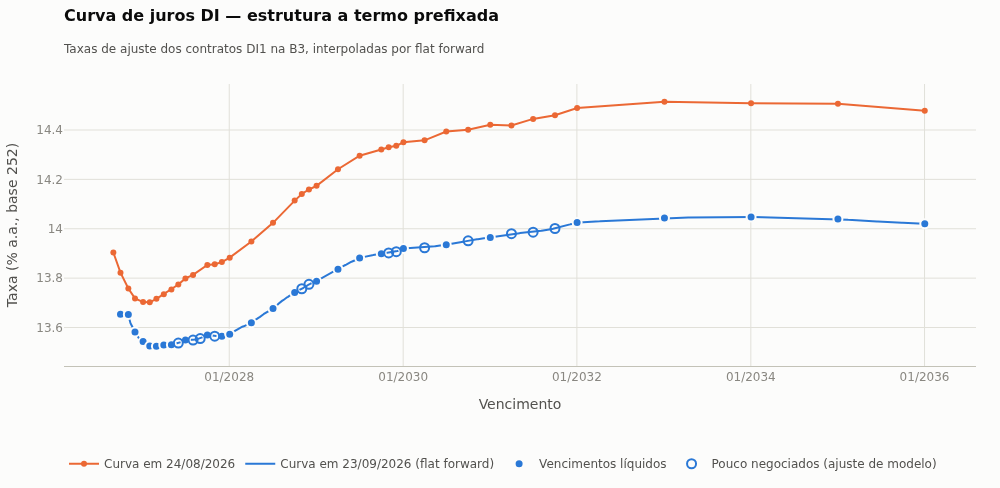

In [5]:
curva = CurvaDI.do_historico(historico)                                  # último pregão
curva_1m = CurvaDI.do_historico(historico, curva.data_referencia - pd.Timedelta(days=30))

graficos.grafico_curva(curva, curva_1m, anos_max=10).show()

In [6]:
tabela = curva.vertices[["codigo", "vencimento", "du", "taxa", "pu", "contratos_abertos", "liquido"]].copy()
tabela["taxa"] = (tabela["taxa"] * 100).round(3)
tabela["variação 1 mês (bps)"] = ((curva.vertices["taxa"] - curva.vertices["codigo"].map(
    curva_1m.vertices.set_index("codigo")["taxa"])) * 1e4).round(1)
tabela.head(15)

,codigo,vencimento,du,taxa,pu,contratos_abertos,liquido,variação 1 mês (bps)
0,DI1V26,2026-10-01,6,13.654,99695.73,6194704.0,True,-16.8
1,DI1X26,2026-11-03,27,13.653,98638.15,1088940.0,True,-10.5
2,DI1Z26,2026-12-01,46,13.582,97702.08,1052226.0,True,-13.6
3,DI1F27,2027-01-04,68,13.543,96630.77,7780126.0,True,-16.0
4,DI1G27,2027-02-01,88,13.525,95666.90,349405.0,True,-17.7
5,DI1H27,2027-03-01,106,13.524,94804.33,355224.0,True,-19.2
6,DI1J27,2027-04-01,128,13.529,93758.20,2330421.0,True,-20.6
7,DI1K27,2027-05-03,149,13.530,92771.53,256179.0,True,-22.4
8,DI1M27,2027-06-01,169,13.537,91838.11,89669.0,False,-23.7
9,DI1N27,2027-07-01,191,13.549,90818.55,2389862.0,True,-25.0


**Taxas a termo (forwards).** A taxa spot de um vencimento é a *média* do CDI até lá. A **forward** entre dois vencimentos é o CDI que o mercado precifica *naquele trecho*, e é nela que aparecem as expectativas: um degrau para baixo no curto prazo indica cortes precificados. Nos vencimentos longos e pouco negociados, os degraus ficam mais ruidosos.

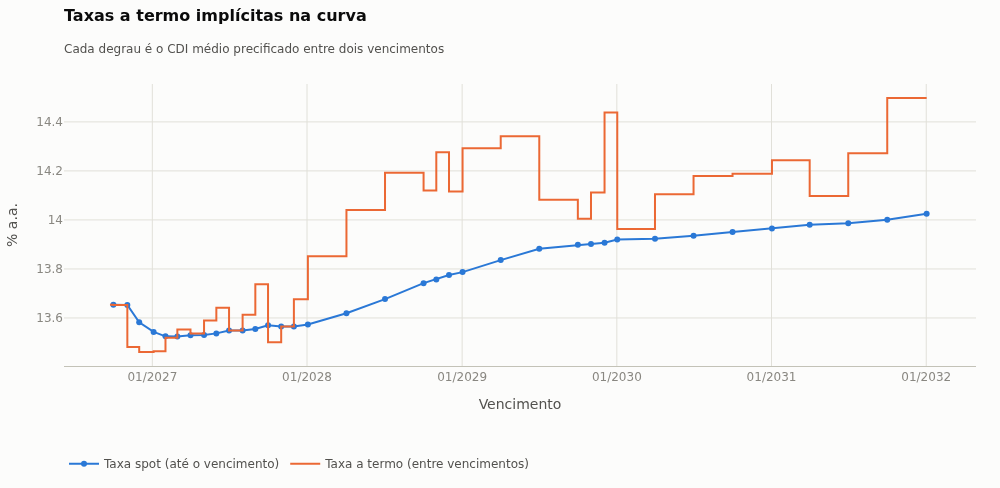

Taxa interpolada para 1 ano (252 du): 13.567% · forward 1A→2A: 13.912%


In [7]:
graficos.grafico_forwards(curva).show()
print(f"Taxa interpolada para 1 ano (252 du): {curva.taxa(252):.3%} · forward 1A→2A: {curva.forward(252, 504):.3%}")

## 5. O que a curva precifica para o Copom

### A ideia

O CDI só muda quando o Copom muda a Selic, e a nova taxa vale **a partir do dia útil seguinte à decisão** (o comunicado sai depois do fechamento). Entre duas reuniões, o CDI é constante. Assim, cada contrato é uma média ponderada dos CDIs de cada intervalo entre reuniões:

$$\ln F(T) = \sum_i \frac{n_i(T)}{252}\,\ln(1+r_i)$$

Aqui, $r_0$ é o CDI de hoje, $r_i$ é o CDI depois da reunião $i$ e $n_i(T)$ são os dias úteis do intervalo $i$ antes do vencimento $T$.

### O algoritmo (bootstrap)

1. **CDI atual ($r_0$):** vem do contrato que vence mais tarde *antes* da próxima reunião, porque ele só embute o CDI atual.
2. Para cada reunião, usa o contrato que vence mais tarde antes da reunião seguinte e resolve $r_i$, já que os anteriores são conhecidos.
3. **Proteção contra ruído:** se o contrato disponível vence poucos dias depois da reunião, 1 bp de erro no ajuste viraria dezenas de bps na reunião. Nesses casos ela é estimada junto com a seguinte e marcada como `agrupada`.
4. **Selic implícita** = CDI implícito + 0,10 p.p. A diferença entre reuniões consecutivas é o **movimento precificado**.

In [8]:
caminho = copom.selic_implicita(curva, reunioes)
print(f"Curva de {curva.data_referencia:%d/%m/%Y} · CDI vigente: {caminho.attrs['cdi_atual']:.2%} "
      f"(via {caminho.attrs['fonte_cdi_atual']}) · Selic vigente implícita: {caminho.attrs['selic_atual']:.2%}")

exibir = caminho.head(8)[["reuniao", "data_decisao", "variacao_bps", "acumulado_bps", "selic_implicita", "contrato", "agrupada"]].copy()
exibir["selic_implicita"] = (exibir["selic_implicita"] * 100).round(2)
exibir.round({"variacao_bps": 1, "acumulado_bps": 1})

Curva de 23/09/2026 · CDI vigente: 13.65% (via contrato DI1X26) · Selic vigente implícita: 13.75%


,reuniao,data_decisao,variacao_bps,acumulado_bps,selic_implicita,contrato,agrupada
0,R7/2026,2026-11-04,-19.2,-19.2,13.56,DI1Z26,False
1,R8/2026,2026-12-09,0.1,-19.1,13.56,DI1F27,False
2,R1/2027,2027-01-27,5.4,-13.8,13.62,DI1H27,False
3,R2/2027,2027-03-17,5.5,-8.3,13.67,DI1M27,True
4,R3/2027,2027-04-28,0.0,-8.3,13.67,DI1M27,True
5,R4/2027,2027-06-16,3.4,-4.9,13.70,DI1Q27,False
6,R5/2027,2027-08-04,7.5,2.6,13.78,DI1V27,True
7,R6/2027,2027-09-22,0.0,2.6,13.78,DI1V27,True


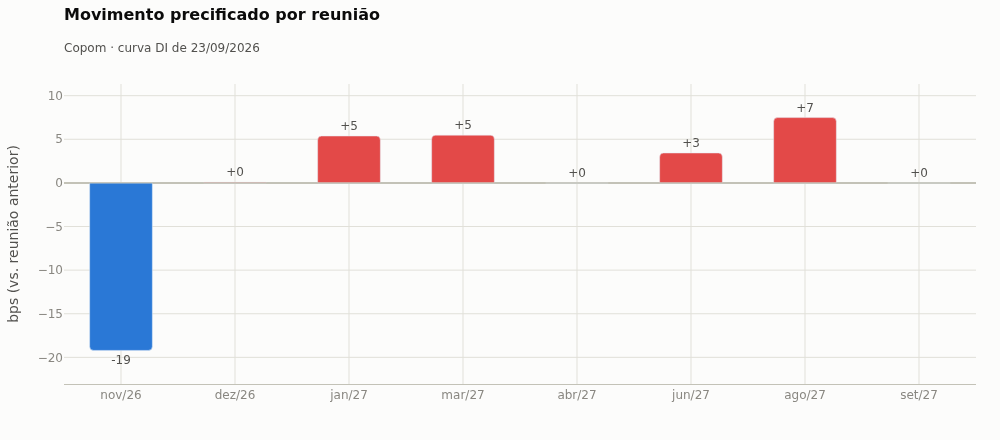

In [9]:
graficos.grafico_copom_variacoes(caminho).show()

**Probabilidades.** O Copom se move em passos de 25 bps. Se a curva precifica, por exemplo, −18 bps, isso equivale a cerca de 72% de chance de corte de 25 bps e 28% de manutenção, por interpolação linear entre os dois passos vizinhos. É uma leitura aproximada, porque a curva também embute prêmio de risco.

In [10]:
prox = caminho.iloc[0]
probs = copom.probabilidades_movimento(prox["variacao_bps"])
texto = " e ".join(f"**{p:.0%}** de {copom.descrever_movimento(k)}" for k, p in sorted(probs.items(), key=lambda x: -x[1]) if p >= 0.01)
display(Markdown(f"Para a reunião de **{prox['data_decisao']:%d/%m/%Y}**, a curva precifica **{prox['variacao_bps']:+.1f} bps**: {texto}."))

Para a reunião de **04/11/2026**, a curva precifica **-19.2 bps**: **77%** de corte de 25 bps e **23%** de manutenção.

### Mercado × economistas (Focus)

O Focus traz a mediana das projeções de economistas para a Selic em cada reunião. A diferença entre a curva e o Focus é o tipo de coisa que se discute numa mesa de juros. Se a curva precifica mais cortes que o Focus, o mercado está mais otimista que os economistas, ou está pagando por um cenário de risco.

Focus indisponível nesta execução. Rode `python scripts/atualizar_dados.py` com internet (ou ATUALIZAR = True) para incluir a comparação.


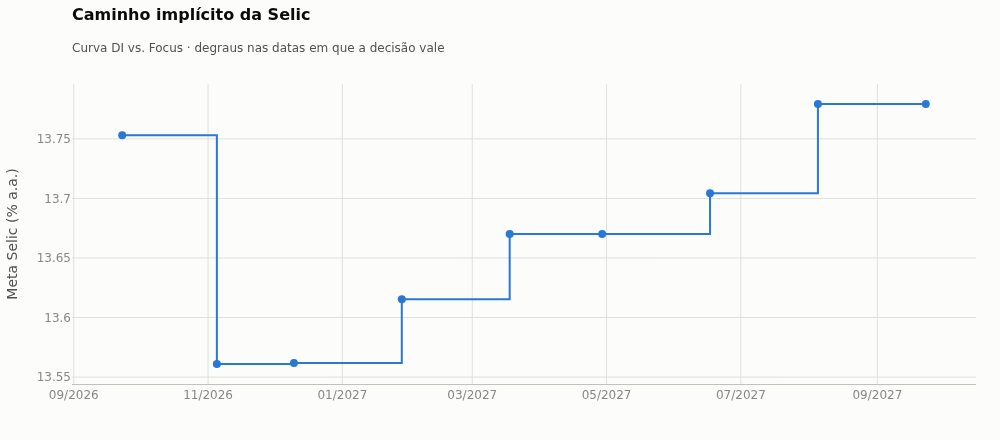

In [11]:
from curva_di.analise import focus_na_data

focus_hoje = focus_na_data(focus, curva.data_referencia)
if focus_hoje is None:
    print("Focus indisponível nesta execução. Rode `python scripts/atualizar_dados.py` com internet "
          "(ou ATUALIZAR = True) para incluir a comparação.")
    graficos.grafico_copom_caminho(caminho).show()
else:
    comparacao = caminho.head(8).merge(focus_hoje[["reuniao", "mediana"]], on="reuniao", how="left")
    comparacao["curva − Focus (bps)"] = (comparacao["selic_implicita"] - comparacao["mediana"]) * 1e4
    display(comparacao[["reuniao", "data_decisao", "selic_implicita", "mediana", "curva − Focus (bps)"]].round(4))
    graficos.grafico_copom_caminho(caminho, focus_hoje).show()

### Validação: o método funciona?

Se o método estiver certo, duas coisas têm de acontecer em cada reunião passada:

1. **A mudança do CDI lida na curva no dia seguinte à decisão tem de bater com a decisão anunciada.** Isso é um teste do método, e usa só dados da B3.
2. **O precificado na véspera tem de ficar perto do decidido**, exceto nas reuniões que surpreenderam o mercado. Isso é uma propriedade do mercado, não do método.

A célula abaixo reconstrói a precificação para todos os dias do histórico coberto pelo calendário.

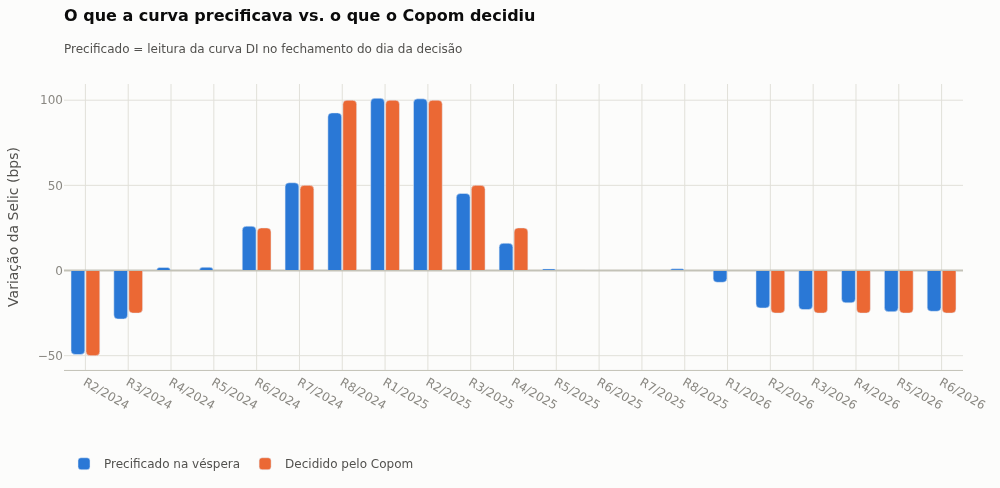

21 reuniões · desvio máximo entre a decisão lida na curva e a anunciada: 1.5 bp
Surpresa média (|decidido − precificado na véspera|): 2.6 bps


,reuniao,data_decisao,precificado_bps,decidido_bps,decidido_curva_bps,surpresa_bps
0,R2/2024,2024-03-20,-49.3,-50.0,-49.6,-0.7
1,R3/2024,2024-05-08,-28.5,-25.0,-24.6,3.5
2,R4/2024,2024-06-19,1.8,0.0,1.0,-1.8
3,R5/2024,2024-07-31,1.9,0.0,1.5,-1.9
4,R6/2024,2024-09-18,26.0,25.0,25.5,-1.0
5,R7/2024,2024-11-06,51.5,50.0,50.8,-1.5
6,R8/2024,2024-12-11,92.5,100.0,100.2,7.5
7,R1/2025,2025-01-29,101.1,100.0,100.3,-1.1
8,R2/2025,2025-03-19,100.8,100.0,100.7,-0.8
9,R3/2025,2025-05-07,45.2,50.0,50.4,4.8


In [12]:
historico_implicito = copom.historico_selic_implicita(historico, reunioes, selic_cdi)
surpresas = copom.surpresas_copom(historico_implicito, reunioes, selic_cdi)

graficos.grafico_surpresas(surpresas).show()
desvio_metodo = (surpresas["decidido_curva_bps"] - surpresas["decidido_bps"]).abs()
print(f"{len(surpresas)} reuniões · desvio máximo entre a decisão lida na curva e a anunciada: {desvio_metodo.max():.1f} bp")
print(f"Surpresa média (|decidido − precificado na véspera|): {surpresas['surpresa_bps'].abs().mean():.1f} bps")
surpresas.round(1)

**Como a precificação evoluiu até a próxima reunião.** O gráfico mostra, dia a dia, quanto de movimento acumulado a curva embutia até a próxima reunião. É uma forma direta de ver o mercado "mudando de ideia" depois de dados de inflação, falas do BC ou choques externos.

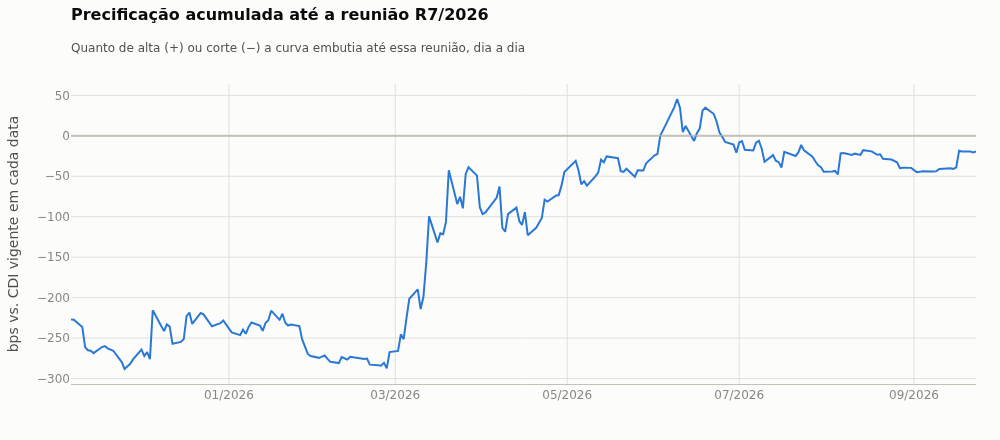

In [13]:
graficos.grafico_precificacao_reuniao(historico_implicito, caminho.iloc[0]["reuniao"]).show()

## 6. Movimentos da curva

### Prazo constante

Os contratos têm vencimento fixo, então o `DI1F28` de hoje é um prazo mais curto que o `DI1F28` de um ano atrás. Para comparar dias diferentes, a curva de cada dia é interpolada em **prazos fixos**: 3M, 6M, 1A, 2A, 3A, 5A e 10A.

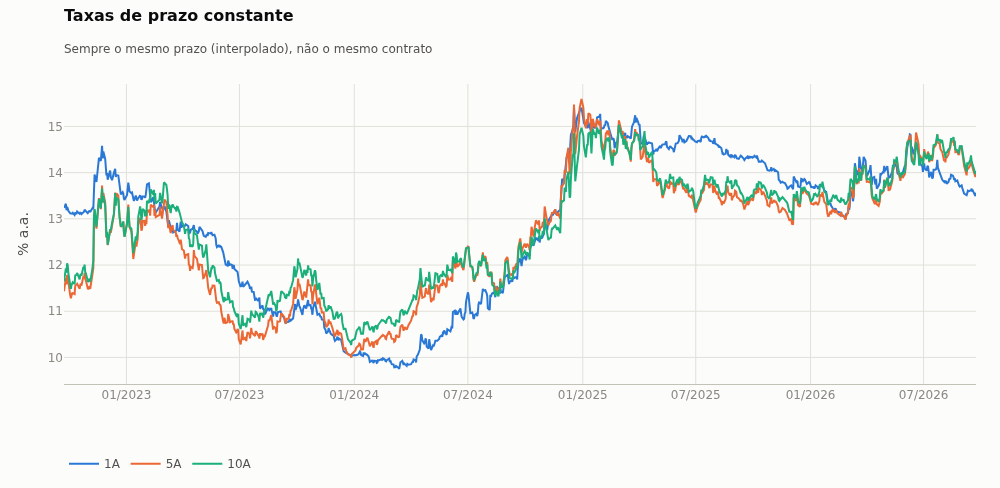

,3M,6M,1A,2A,3A,5A,10A
data,,,,,,,
2026-09-17,13.568,13.540,13.590,13.787,13.972,14.111,14.205
2026-09-18,13.564,13.545,13.605,13.789,13.952,14.080,14.167
2026-09-21,13.557,13.520,13.531,13.669,13.831,13.956,14.032
2026-09-22,13.542,13.501,13.495,13.626,13.784,13.906,13.970
2026-09-23,13.549,13.529,13.567,13.739,13.899,14.003,14.036


In [14]:
taxas = vertices_constantes(historico)          # decimal; índice = data, colunas = vértices
variacoes = movimentos.variacoes_bps(taxas)     # variação diária em bps

graficos.grafico_historico_vertices(taxas, desde=taxas.index[-1] - pd.DateOffset(years=4)).show()
(taxas.tail(5) * 100).round(3)

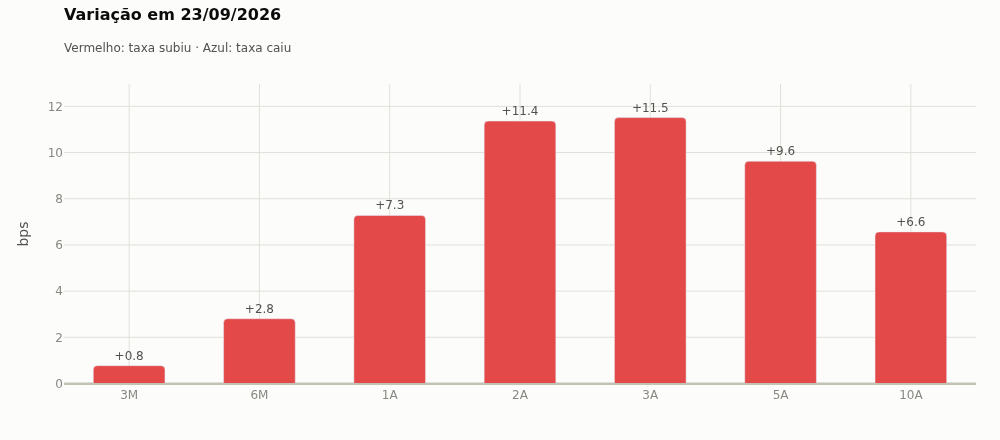

In [15]:
graficos.grafico_variacao_dia(variacoes.iloc[-1], variacoes.index[-1]).show()

### Regimes: bull/bear, steepening/flattening

Um jeito rápido de descrever o dia é olhar a variação de um vértice curto (1A) e de um longo (5A):

| Regime | Definição | Leitura típica |
|---|---|---|
| **Bear steepening** | taxas sobem, o longo sobe mais | prêmio de risco (fiscal, inflação de longo prazo) |
| **Bear flattening** | taxas sobem, o curto sobe mais | mercado precifica mais aperto monetário |
| **Bull steepening** | taxas caem, o curto cai mais | mercado antecipa cortes da Selic |
| **Bull flattening** | taxas caem, o longo cai mais | alívio de prêmio de risco, demanda por duration |
| **Twist** | curto e longo em direções opostas | mudança de inclinação sem mudança de nível |

*Bear* e *bull* se referem ao **preço**: taxa subindo significa preço caindo, e o mercado é "bear".

In [16]:
tabela_regimes = movimentos.regimes(variacoes)
display(movimentos.frequencia_regimes(tabela_regimes).round(1))
tabela_regimes.tail(10).round(1)

,dias,% dos dias
regime,,
Bear steepening,64,25.4
Bear flattening,18,7.1
Bull steepening,33,13.1
Bull flattening,65,25.8
Twist steepening,18,7.1
Twist flattening,16,6.3
Alta paralela,12,4.8
Queda paralela,19,7.5
Estável,7,2.8


,Δ1A (bps),Δ5A (bps),Δ inclinação 1A–5A (bps),regime
data,,,,
2026-09-10,1.8,-5.7,-7.5,Twist flattening
2026-09-11,-1.0,1.9,2.9,Twist steepening
2026-09-14,1.5,6.7,5.2,Bear steepening
2026-09-15,0.6,9.7,9.2,Bear steepening
2026-09-16,3.5,-9.9,-13.4,Twist flattening
2026-09-17,-6.3,-5.1,1.3,Bull steepening
2026-09-18,1.6,-3.1,-4.6,Twist flattening
2026-09-21,-7.4,-12.4,-5.1,Bull flattening
2026-09-22,-3.7,-5.0,-1.3,Bull flattening


### PCA: os três fatores que movem a curva

A análise de componentes principais (PCA) sobre as variações diárias mostra que **quase todo o risco da curva vem de poucos fatores**. Três deles têm leitura econômica clara:

- **Nível:** a curva inteira sobe ou desce. Costuma explicar perto de 90% da variância.
- **Inclinação:** o curto e o longo andam em direções opostas.
- **Curvatura:** a barriga (2–3 anos) se move em relação às pontas.

Na prática, é por isso que mesas pensam o risco em "DV01 total" (nível) e em posições de inclinação e butterfly.

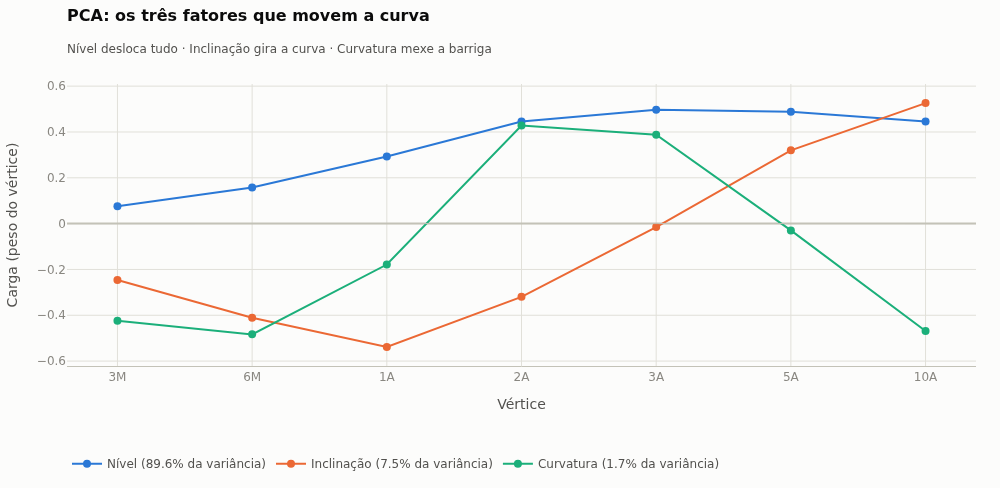

,variancia_explicada_%,acumulada_%,desvio_diario_bps
Nível,89.59,89.59,29.35
Inclinação,7.51,97.10,8.50
Curvatura,1.73,98.83,4.08


In [17]:
pca = movimentos.pca_curva(variacoes)
graficos.grafico_pca(pca).show()
pca.resumo().round(2)

### Inclinação: z-score e percentil

A inclinação 1A–5A (taxa do 5A menos taxa do 1A) resume o formato da curva. O z-score compara o valor atual com a média e o desvio dos últimos 12 meses.

Inclinação 1A–5A: **44 bps** · z-score 12m: **+1.2** · percentil 12m: **82**

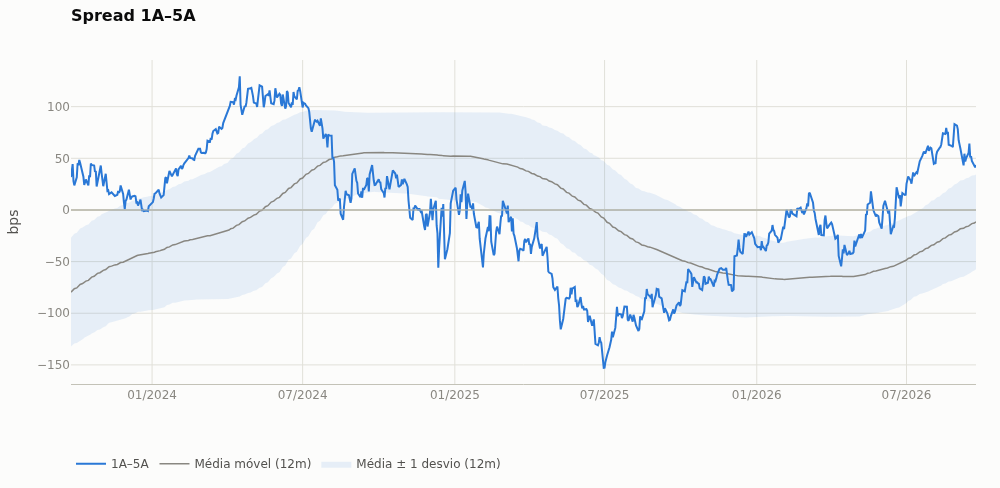

In [18]:
spreads = movimentos.spreads(taxas)
inclinacao = spreads["1A–5A"]
z = movimentos.zscore(inclinacao).iloc[-1]
display(Markdown(f"Inclinação 1A–5A: **{inclinacao.iloc[-1]:.0f} bps** · z-score 12m: **{z:+.1f}** · "
                 f"percentil 12m: **{movimentos.percentil_atual(inclinacao):.0f}**"))
graficos.grafico_spread(inclinacao, "1A–5A", desde=taxas.index[-1] - pd.DateOffset(years=3)).show()

### Maiores movimentos e reação ao Copom

Os maiores movimentos do 5A no histórico, e a reação da curva no pregão seguinte a cada decisão do Copom. Como o comunicado sai depois do fechamento, a reação é medida do fechamento do dia da decisão ao fechamento do dia seguinte.

In [19]:
display(movimentos.maiores_movimentos(variacoes, "5A", 8))
movimentos.reacao_copom(taxas, reunioes).tail(8).round(1)

,regime,3M,6M,1A,2A,3A,5A,10A
data,,,,,,,,
2020-03-18,Bear steepening,23.0,37.0,54.5,141.7,165.4,140.1,114.5
2020-04-24,Bear steepening,24.5,34.2,53.5,78.8,110.0,136.2,129.7
2020-03-12,Bear steepening,24.1,48.4,86.6,121.5,135.1,132.6,126.1
2022-11-10,Bear steepening,4.5,17.5,49.5,97.6,110.2,106.3,95.1
2020-03-13,Bull flattening,-33.5,-56.0,-73.3,-93.6,-111.3,-104.6,-99.6
2020-04-28,Bull flattening,-19.8,-32.8,-50.3,-52.0,-89.1,-87.5,-73.1
2020-03-25,Bull flattening,-3.2,-10.7,-32.4,-57.9,-84.8,-86.2,-77.4
2020-03-11,Bear steepening,16.2,23.4,36.2,55.4,70.7,70.8,68.3


,reuniao,data_decisao,Δ6M,Δ1A,Δ2A,Δ5A,Δ10A,regime
14,R7/2025,2025-11-05,1.4,2.8,1.9,2.9,2.6,Alta paralela
15,R8/2025,2025-12-10,-0.1,-1.0,-8.0,-9.1,-9.4,Bull flattening
16,R1/2026,2026-01-28,-0.9,-6.1,-10.6,-5.4,-3.1,Queda paralela
17,R2/2026,2026-03-18,-10.8,-11.4,-9.7,-9.1,-5.9,Bull steepening
18,R3/2026,2026-04-29,-6.3,-12.0,-18.4,-17.5,-15.0,Bull flattening
19,R4/2026,2026-06-17,-6.1,5.3,22.3,27.2,24.5,Bear steepening
20,R5/2026,2026-08-05,1.0,4.7,8.7,13.2,13.3,Bear steepening
21,R6/2026,2026-09-16,-3.7,-6.3,-5.8,-5.1,-4.2,Bull steepening


## 7. Carry, roll-down e valor relativo

Para quem **dá taxa** num prazo $m$, com horizonte $h$ e supondo a **curva parada**:

- **Carry** $= f(h, m) - y(m)$: quanto a taxa a termo está acima da spot.
- **Roll-down** $= y(m) - y(m-h)$: o contrato envelhece e passa a ser precificado por um ponto mais curto da curva.
- **Carry + roll** $= f(h,m) - y(m-h)$: quanto a taxa pode subir até o horizonte antes de a posição perder dinheiro.

Dividir pelo risco (volatilidade no horizonte) permite comparar vértices. É a métrica mais básica para escolher **onde** se posicionar na curva.

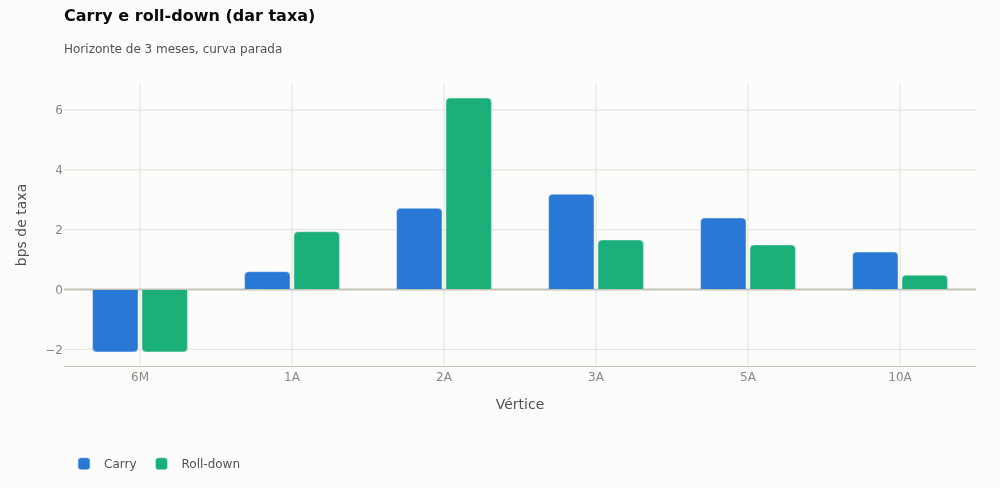

,du,taxa_%,forward_%,carry_bps,roll_down_bps,carry_roll_bps,dv01_R$,vol_horizonte_bps,carry_roll/vol
vertice,,,,,,,,,
6M,126,13.53,13.51,-2.08,-2.09,-4.17,4.13,42.77,-0.10
1A,252,13.57,13.57,0.60,1.93,2.53,7.75,76.41,0.03
2A,504,13.74,13.77,2.71,6.40,9.11,13.59,101.09,0.09
3A,756,13.90,13.93,3.18,1.66,4.84,17.83,103.36,0.05
5A,1260,14.00,14.03,2.39,1.49,3.88,22.78,96.99,0.04
10A,2520,14.04,14.05,1.25,0.48,1.73,23.58,87.36,0.02


In [20]:
carry = valor_relativo.carry_roll(curva, horizonte_du=63, variacoes=variacoes)
graficos.grafico_carry(carry).show()
carry.round(2)

**Triagem de inclinações e butterflies.** Para cada spread, a tabela traz o nível atual, o z-score, o percentil e, quando o spread está esticado ($|z| \ge 1$), a posição de **reversão à média**, com o carry + roll dessa posição e quantos contratos do vértice curto neutralizam o DV01 de um contrato longo.

> É uma **triagem estatística**, não uma recomendação: um spread pode continuar esticado por muito tempo quando existe um motivo macro para isso. O próximo passo natural é um backtest de cada sinal.

In [21]:
valor_relativo.triagem_valor_relativo(taxas, curva).round(2)

,tipo,atual_bps,media_bps,desvio_bps,z_score,percentil,sugestao,carry_roll_bps,contratos_curto_por_longo
spread,,,,,,,,,
1A–2A,inclinação,17.20,-33.17,39.65,1.27,83.33,flattener: dar 2A / tomar 1A,6.58,1.75
1A/3A/5A,butterfly,22.84,-47.67,57.83,1.22,81.75,"dar barriga (3A) / tomar asas (1A, 5A)",3.27,NaN
1A–5A,inclinação,43.52,-11.49,45.79,1.20,82.14,flattener: dar 5A / tomar 1A,1.35,2.94
1A/2A/5A,butterfly,-9.13,-54.86,41.19,1.11,89.68,"dar barriga (2A) / tomar asas (1A, 5A)",11.82,NaN
3M–1A,inclinação,1.79,-51.36,52.77,1.01,77.78,flattener: dar 1A / tomar 3M,NaN,3.64
2A/5A/10A,butterfly,22.97,11.58,14.79,0.77,73.81,neutro,NaN,NaN
6M/1A/2A,butterfly,-13.33,-1.04,17.02,-0.72,28.57,neutro,NaN,NaN
5A–10A,inclinação,3.36,10.11,10.80,-0.63,21.03,neutro,NaN,1.04
2A–5A,inclinação,26.33,21.69,18.01,0.26,52.78,neutro,NaN,1.68


## 8. Comentário de mercado automático

Com tudo isso, o projeto escreve um parágrafo no estilo do resumo diário de uma mesa de juros. O texto junta o regime do dia, a inclinação contra o histórico e a mudança na precificação do Copom.

In [22]:
from curva_di.analise import montar_analise

a = montar_analise(historico=historico)   # junta curva, Copom (hoje e no pregão anterior) e movimentos
display(Markdown(comentario.comentario_do_dia(a.taxas, caminho_hoje=a.caminho, caminho_anterior=a.caminho_anterior)))

**23/09/2026 — Bear steepening.** O 1A variou +7,3 bps (para 13,57%) e o 5A +9,6 bps (para 14,00%); a inclinação 1A–5A mudou +2,3 bps e está em 44 bps (z-score +1,2 em 12 meses, percentil 82). Leitura: juros sobem puxados pela ponta longa — em geral, aumento de prêmio de risco (fiscal, inflação de longo prazo) mais do que mudança na Selic esperada. Na ponta longa, o 10A andou +6,6 bps. Para a próxima reunião do Copom (04/11), a curva precifica -19,2 bps (77% de chance de corte de 25 bps), ante -20,4 bps no pregão anterior. Até a reunião de 09/12/2026, o movimento acumulado precificado é -19,1 bps, levando a Selic implícita a 13,56%.

## 9. Dashboard, figuras e testes

**Dashboard interativo** (Streamlit), com abas de curva e Copom, movimentos e valor relativo, seletor de data e botão para atualizar os dados:

```bash
streamlit run app/dashboard.py
```

**Figuras do README** (salvas em `docs/img/`):

```bash
python scripts/gerar_figuras.py
```

**Testes automatizados** (calendário, fórmulas do DI1, bootstrap do Copom, PCA, leitura do arquivo da B3):

```bash
pytest
```

## 10. Mapa do código e próximos passos

| Módulo (`src/curva_di/`) | Responsabilidade |
|---|---|
| `calendario.py` | Feriados (por regra), dias úteis padrão B3/ANBIMA, vencimentos do DI1 |
| `dados.py` | Download do boletim da B3, do espelho histórico e das séries do BCB; cache em `data/` |
| `curva.py` | PU, taxa, DV01, forwards, interpolação flat forward, `CurvaDI`, vértices de prazo constante |
| `copom.py` | Calendário do Copom, Selic implícita por reunião, probabilidades, surpresas |
| `movimentos.py` | Variações, spreads, PCA, regimes, maiores movimentos, reação ao Copom |
| `valor_relativo.py` | Carry, roll-down e triagem de inclinações e butterflies |
| `comentario.py` | Comentário de mercado automático |
| `graficos.py` | Todos os gráficos (Plotly) |
| `analise.py` | Junta tudo para uma data (usado pelo dashboard e pelas figuras) |

**Extensões naturais:**

- **Inflação implícita (breakeven):** montar a curva real a partir das NTN-B (ou do DAP) e comparar com a pré, para chegar à inflação precificada por prazo.
- **Backtest:** testar a regra de reversão à média da triagem, com custos, drawdown e em que cenários ela falha.
- **Event study ampliado:** medir a reação da curva a divulgações de IPCA e a anúncios fiscais, além do Copom.
- **Spread Selic–CDI dinâmico:** usar a diferença observada no BCB em vez dos 0,10 p.p. fixos.

A metodologia detalhada, com todas as fórmulas, está em [`docs/metodologia.md`](../docs/metodologia.md).

## 11. Glossário

| Termo | Significado |
|---|---|
| **bp (ponto-base)** | 0,01 ponto percentual. 13,65% → 13,75% é uma alta de 10 bps |
| **Base 252** | Convenção brasileira: juros compostos por dias úteis, com 252 dias úteis no ano |
| **CDI** | Taxa média dos empréstimos de um dia entre bancos; anda colada na Selic |
| **Copom** | Comitê de Política Monetária do BCB; define a meta Selic em 8 reuniões por ano |
| **Dar taxa / tomar taxa** | Apostar na queda / na alta dos juros (comprar / vender PU) |
| **DI1** | Contrato futuro de DI de um dia da B3; vale R$ 100.000 no vencimento |
| **DV01** | Variação do valor da posição (R$) para 1 bp de variação na taxa |
| **Flat forward** | Interpolação que supõe taxa a termo constante entre dois vértices |
| **Forward (taxa a termo)** | Taxa implícita entre duas datas futuras |
| **Focus** | Pesquisa semanal do BCB com as projeções de economistas |
| **PCA** | Análise de componentes principais: decompõe os movimentos da curva em fatores independentes |
| **PU** | Preço unitário do contrato |
| **Steepening / flattening** | A curva fica mais inclinada / mais plana |
| **Bull / bear** | Preço subindo (taxa caindo) / preço caindo (taxa subindo) |
| **Vértice** | Um ponto (prazo) da curva |
| **Z-score** | Quantos desvios-padrão o valor atual está da média da janela |